<a href="https://colab.research.google.com/github/Katrin-Pochtar/Kaggle/blob/main/%D0%9F%D0%BE%D1%87%D1%82%D0%B0%D1%80_%D0%9A%D0%B0%D1%82%D1%80%D0%B8%D0%BD_%D0%92%D0%B8%D0%BA%D1%82%D0%BE%D1%80%D0%BE%D0%B2%D0%BD%D0%B0_%D0%A1%D0%BE%D1%80%D0%B5%D0%B2%D0%BD%D0%BE%D0%B2%D0%B0%D1%82%D0%B5%D0%BB%D1%8C%D0%BD%D1%8B%D0%B8%CC%86_DS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# План домашних заданий





- Описание задачи и знакомство с данными.
- Домашнее задание 1. Генерация и фильтрация признаков.
- Домашнее задание 2. Прогноз времени и вида поломки машин, настройка ML-модели.
- Домашнее задание 3. Оптимизация. Тюнинг гиперпараметров с помощью `Optuna`.
- Домашнее задание 4. Блендинг.
- Домашнее задание 5. Парсинг внешних данных и оптимизация памяти.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import data_table
data_table.enable_dataframe_formatter()

# <center id="part0"> Описание задачи

**Предыстория:**  мы работаем с каршеринговой компанией, которая управляет крупным автопарком машин. Наша цель — предотвратить длительные периоды простоя машин из-за поломок через своевременное обслуживание и ремонт.


**Идея для решения проблемы:** создать приоритизированный список обхода машин. Этот список поможет технической бригаде сосредоточиться на автомобилях, которые наиболее вероятно выйдут из строя в ближайшее время.


**Как компания решает задачу:**

* собирает данные о поездках и состоянии машин до поломок;

* нанимает Data Scientist, чтобы он смог использовать эти данные для анализа и прогнозирования характера поломок.

**Важный момент**: задачи этого специалиста (Data Scientist) предстоит выполнять вам.

## <center> Знакомство с данными

### Информация про машины с таргетом (основной датасет)

In [ ]:
car_train = pd.read_csv('https://raw.githubusercontent.com/a-milenkin/Competitive_Data_Science/main/data/car_train.csv')
car_train.sample(5)

,car_id,model,car_type,fuel_type,car_rating,year_to_start,riders,year_to_work,target_reg,target_class
992,a51887682f,Smart Coupe,economy,petrol,3.98,2013,46432,2014,43.03,engine_check
1942,m-2207671H,Smart ForFour,economy,petrol,4.60,2017,122522,2020,42.65,engine_overheat
300,H82330164N,Smart ForFour,economy,petrol,2.74,2017,128991,2016,45.72,engine_check
302,a-1300283K,Kia Rio X-line,economy,petrol,5.02,2014,59340,2017,63.73,engine_ignition
411,P13663597M,Kia Sportage,standart,petrol,4.16,2015,77634,2016,57.08,engine_ignition


- `car_id` — идентификатор машины;
- `model` / `car_type` / `fuel_type` — марка, класс и тип топлива машины;
- `car_rating` / `riders` — общий рейтинг и общее число поездок к концу 2021 года;
- `year_to_start` / `year_to_work` — год выпуска машины и год начала работы в автопарке;
- `target_reg` — количество дней до поломки;
- `target_class` — класс поломки (всего 9 видов).

(2337, 10)


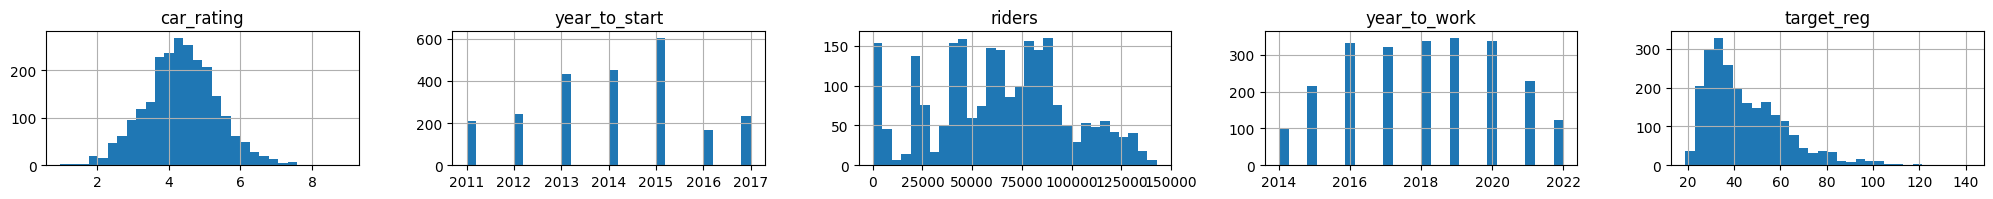

In [ ]:
print(car_train.shape)
car_train.hist(figsize=(25, 4), layout=(2, 5), bins=30);

### Информация про поездки

In [ ]:
rides_info = pd.read_csv('https://raw.githubusercontent.com/a-milenkin/Competitive_Data_Science/main/data/rides_info.csv')
rides_info.sample(5)

,user_id,car_id,ride_id,ride_date,rating,ride_duration,ride_cost,speed_avg,speed_max,stop_times,distance,refueling,user_ride_quality,deviation_normal
144652,w41871175a,K-4627145s,R1q,2020-01-31,6.86,34,538,46,57.0,0,1051.359025,0,20.344474,3.626
90868,z21302561J,G15557106t,f1n,2020-01-22,4.82,15,144,25,77.0,1,234.958848,0,2.721627,14.351
726110,c10434858x,z-1598953V,f1M,2020-01-05,1.33,23,178,28,41.0,1,515.874763,0,-0.108718,1.967
713836,j19445521c,y-2198122N,q1Y,2020-02-16,3.86,683,7507,38,65.0,2,1561.262491,0,2.937636,2.364
710599,P14180305Z,y-1159389K,Z1y,2020-03-24,7.23,61,3045,51,118.0,0,1596.338772,0,-4.117543,4.119


- `user_id` / `car_id` / `ride_id` — идентификаторы водителя, машины и поездки соответственно;
- `ride_date` / `rating` — дата поездки и рейтинг, поставленный водителем;
- `ride_duration` / `distance` / `ride_cost` —  длительность (время),  пройденное расстояние, стоимость поездки;
- `speed_avg` / `speed_max` — средняя и максимальная скорости поездки соответственно;
- `stop_times` / `refueling` — количество остановок (паузы) и флаг: была ли дозаправка;
- `user_ride_quality` — оценка манеры вождения водителя машины, определенная скоринговой ML-системой сервиса;
- `deviation_normal` — общий показатель датчиков о состоянии машины, относительно эталонных показателей (нормы).

(739500, 14)


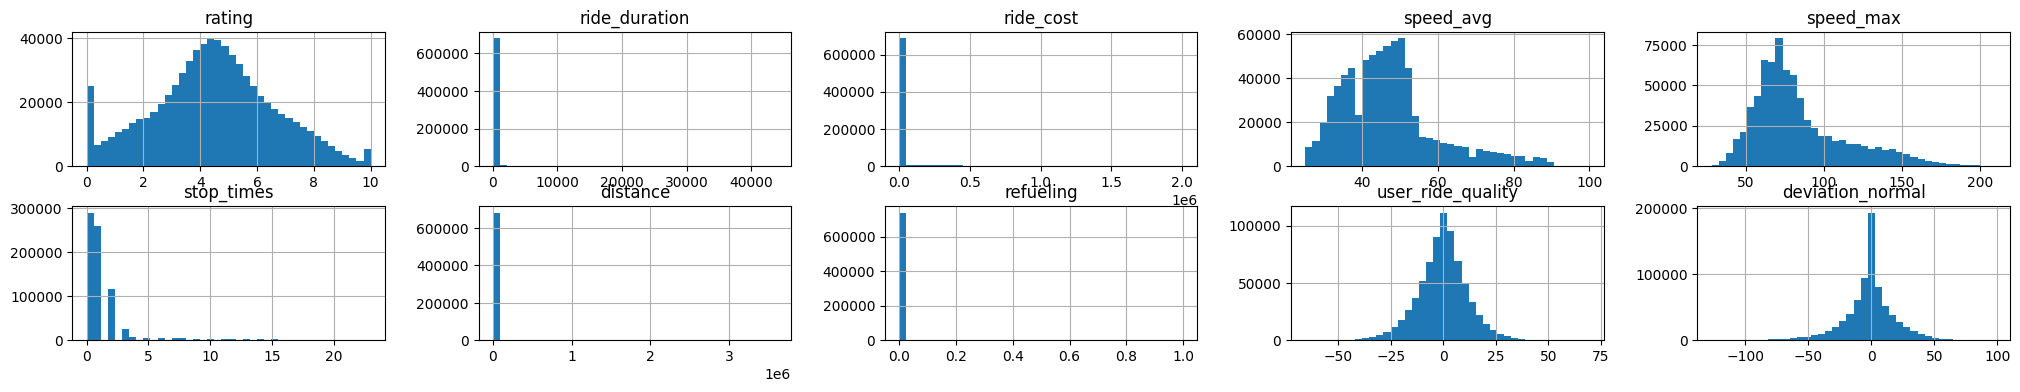

In [ ]:
print(rides_info.shape)
rides_info.hist(figsize=(25, 4), layout=(2, 5), bins=40);

In [ ]:
rides_info.nunique()

,0
user_id,15153
car_id,4250
ride_id,2704
ride_date,93
rating,1001
ride_duration,31651
ride_cost,65021
speed_avg,76
speed_max,261673
stop_times,24


### Информация про водителей

In [ ]:
driver_info = pd.read_csv('https://raw.githubusercontent.com/a-milenkin/Competitive_Data_Science/main/data/driver_info.csv')
driver_info.sample(5)

,age,user_rating,user_rides,user_time_accident,user_id,sex,first_ride_date
10394,30,9.4,723,16.0,q14272016d,1,2019-5-8
9155,40,8.0,2027,12.0,Q61925653H,0,2021-10-25
13779,41,8.1,856,5.0,P60842443a,0,2019-4-4
998,27,8.6,156,15.0,W11119296S,1,2019-10-6
3066,38,8.1,506,NaN,A10963433i,0,2020-6-23


- `user_id` / `age` / `sex` — идентификатор, возраст и пол водителя соответственно;
- `user_rating` — общий рейтинг пользователя за все поездки к концу 2021 года;
- `user_rides` — общее количество поездок к концу 2021 года;
- `user_time_accident` — число инцидентов (это могли быть аварии/штрафы/эвакуация машины);  
- `first_ride_date` — дата первой поездки.

(15153, 7)


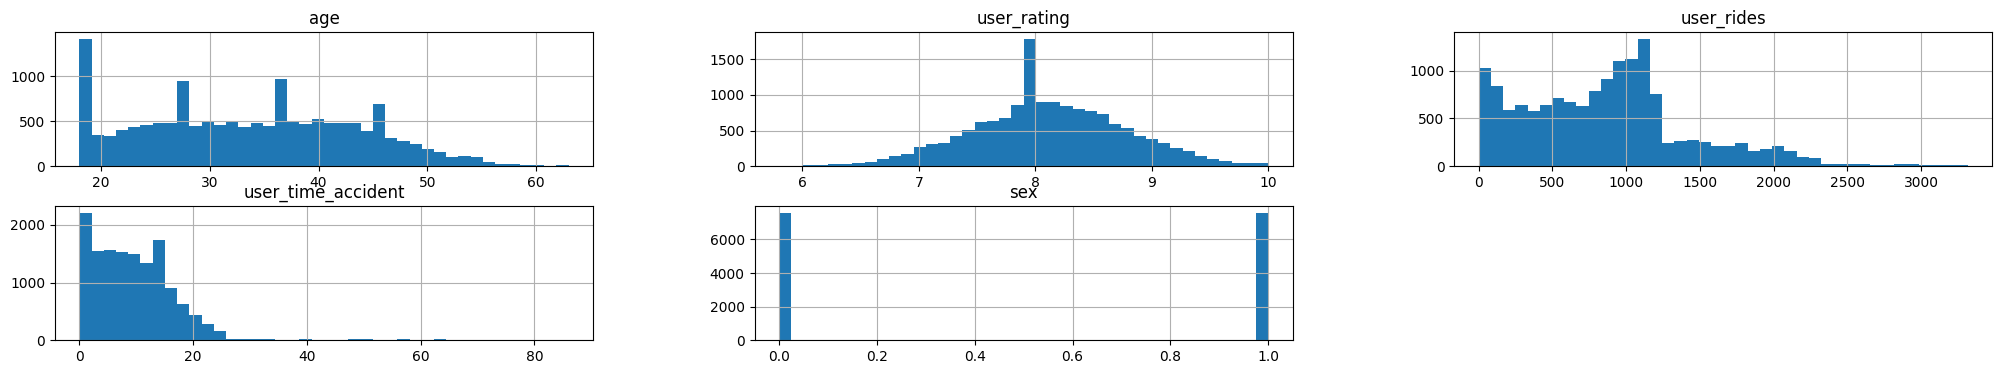

In [ ]:
print(driver_info.shape)
driver_info.hist(figsize=(25, 4), layout=(2, 3), bins=40);

In [ ]:
driver_info.nunique()

,0
age,46
user_rating,43
user_rides,1800
user_time_accident,84
user_id,15153
sex,2
first_ride_date,1653


### Информация про ремонт машин

In [ ]:
fix_info = pd.read_csv('https://raw.githubusercontent.com/a-milenkin/Competitive_Data_Science/main/data/fix_info.csv')
fix_info.sample(5)

,car_id,worker_id,fix_date,work_type,destroy_degree,work_duration
87141,g-2265044F,HB,2019-1-5 3:38,reparking,1.0,20
118569,C58608888l,LZ,2018-2-8 8:18,reparking,1.0,29
13625,m-2601611a,KK,2019-5-19 16:32,reparking,1.0,32
33705,n-2837743g,AV,2020-6-28 17:38,reparking,9.0,51
101371,T-9875021z,LP,2021-10-15 22:17,reparking,1.0,26


- `worker_id` / `car_id` — идентификатор работника и машины;
- `work_type` / `work_duration` — тип и длительность (в часах) проводимой работы;
- `destroy_degree` — степень износа/поврежденности машины в случае поломки;
- `fix_date` — время начала ремонта (снятия машины с линии).

(146000, 6)


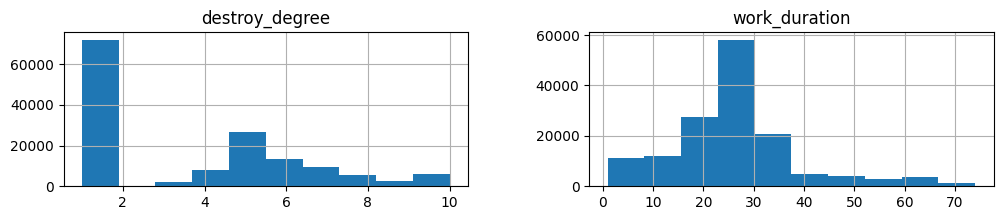

In [ ]:
print(fix_info.shape)
fix_info.hist(figsize=(12, 2));

# Домашнее задание 1. Генерация и фильтрация признаков

<center> <img src="https://ucarecdn.com/bf4c772d-b67a-42ae-a48b-cfd83910b0a2/" width=700>

<div class="alert alert-info">

**Цель блока** — сгенерировать признаки из дополнительных датасетов и добавить их к основному датасету, произвести фильтрацию признаков.

    
## 1. Генерация признаков из дополнительных датасетов (6 баллов)

<div class="alert alert-info">

1. Возьмите датасет `rides_info` с информацией о поездках и проведите группировку по каждой машине отдельно.

2. Для каждой машины (то есть для каждого `car_id`) подсчитайте несколько признаков:
  - минимальный рейтинг за все поездки;
  - средний рейтинг за все поездки;
  - общее количество километров, которое машина проехала;
  - максимальную скорость;
  - общее количество поездок для каждой машины.

3. Добавьте минимум 3 признака на свой выбор.

4. Сделайте соединение таблиц — вспомните про методы соединения и выберите подходящий для этого случая.

5. Подключите информацию про водителей (`driver_info`) и про ремонт машин (`fix_info`). Добавьте минимум 3 любых признака с каждого датасета.

**Обязательно.** Проверьте, что количество строк в полученном датафрейме равно изначальному количеству строк в исходном датасете car_train. Убедитесь, что нет дублей (за это будут снижать баллы).


<h4> Критерии оценивания </h4>
    
- Добавлены 5 обязательных и минимум 3 любых признака из датасета `rides_info` — 2 балла.
- Добавлены минимум 3 любых признака из датасета `driver_info` — 2 балла.
- Добавлены минимум 3 любых признака из датасета `fix_info` — 2 балла.

</div>

<div class="alert alert-success">
    
<h4> Советы по Feature Engineering</h4>
    
- Начинайте с сырых данных.
- Используйте все доступные данные. Покрывайте признаками всю имеющуюся информацию в данных.
- Формулируйте предположения: от чего зависит таргет?
- Смотрите визуально на классы/ошибки и делайте предположения. Какие полезны?
- Помните, что слишком много признаков может быть вредно. Потом придется отфильтровывать.
    
<h4> Полезные источники </h4>
    
- Занятие про Feature Engineering.
- Занятие про Feature Selection.
- [Max Kuhn and Kjell Johnson. Feature Engineering and Selection: A Practical Approach for Predictive Models](http://www.feat.engineering/).

### Feature Engineering

### Идеи для новых признаков


* `feature_min_max_diff` — разница между максимальным и минимальным значениями `deviation_normal` для каждой машины;
* `feature_corner` — угол наклона по признаку `user_ride_quality` для каждой машины;
* `feature_mean` — среднее значение `deviation_normal` для каждой машины;
* `feature_shift` — точка перегиба/сдвига для `deviation_normal`;
* `feature_start` — значение точки старта для `deviation_normal`;
* `feature_nans` — сумма пропусков для столбца `...` для каждой машины;
* `feature_quant` — `X %` квантиль для столбца `...` для каждой машины.

Подумайте, какие из признаков могут оказаться самыми полезными?

### Features rides_info

In [ ]:
def slope(series):
    y = series.dropna().values
    if len(y) < 2:
        return 0
    x = np.arange(len(y))
    return np.polyfit(x, y, 1)[0]

In [ ]:
rides_info['ride_date'] = pd.to_datetime(rides_info['ride_date'])

rides_features = rides_info.groupby('car_id').agg(
    # обязательные
    rating_min=('rating', 'min'),
    rating_mean=('rating', 'mean'),
    distance_total=('distance', 'sum'),
    speed_max_max=('speed_max', 'max'),
    ride_count=('car_id', 'count'),
    # свои
    user_ride_quality_mean=('user_ride_quality', 'mean'),
    deviation_normal_mean=('deviation_normal', 'mean'),
    deviation_normal_std=('deviation_normal', 'std'),
    deviation_min_max_diff=('deviation_normal', lambda x: x.max() - x.min()),
    ride_quality_slope=('user_ride_quality', slope)
)

In [ ]:
rides_features.head()

,rating_min,rating_mean,distance_total,speed_max_max,ride_count,user_ride_quality_mean,deviation_normal_mean,deviation_normal_std,deviation_min_max_diff,ride_quality_slope
car_id,,,,,,,,,,
A-1049127W,0.1,4.255172,1.125753e+07,179.729652,174,0.226325,-6.136672,7.334852,31.688,0.013702
A-1079539w,0.1,4.088046,1.912765e+07,184.505566,174,1.426051,47.443270,17.748271,74.349,-0.163212
A-1162143G,0.1,4.662299,2.995194e+06,180.000000,174,0.515958,10.556425,9.303275,46.177,0.016630
A-1228282M,0.1,4.225172,1.793685e+07,182.446070,174,-12.992128,9.810747,17.627168,64.898,-0.138497
A-1339912r,0.1,4.690115,1.202552e+07,152.000000,174,-9.806267,22.965937,10.392346,40.142,-0.056324


In [ ]:
rides_features.nunique()

,0
rating_min,107
rating_mean,3892
distance_total,4250
speed_max_max,3495
ride_count,1
user_ride_quality_mean,4250
deviation_normal_mean,4242
deviation_normal_std,4250
deviation_min_max_diff,3616
ride_quality_slope,4250


### Features driver_info

In [ ]:
rides_with_driver = rides_info[['car_id', 'user_id']].merge(driver_info, on='user_id', how='left')

driver_features = rides_with_driver.groupby('car_id').agg(
    driver_age_mean=('age', 'mean'),
    driver_rating_mean=('user_rating', 'mean'),
    driver_accidents_mean=('user_time_accident', 'mean'),
)

### Features fix_info

In [ ]:
fix_info["worker_speed"] = fix_info.groupby("worker_id")["work_duration"].transform("mean")
fix_info["worker_experience"] = fix_info.groupby("worker_id")["car_id"].transform("count")

f_nuniq = lambda x: x.nunique()
first_mode = lambda x: x.value_counts().index[0]

fix_features = fix_info.groupby("car_id", as_index=False).agg(
    worker_count=("worker_id", "count"),
    work_duration_mean=("work_duration", "mean"),
    work_duration_max=("work_duration", "max"),
    destroy_degree_std=("destroy_degree", "std"),
    destroy_degree_sum=("destroy_degree", "sum"),
    work_type_nuniq=("work_type", f_nuniq),
    work_type_mode=("work_type", first_mode),
    worker_speed_mean=("worker_speed", "mean"),
    worker_experience_mean=("worker_experience", "mean"),
)

fix_features["work_type_mode"] = fix_features["work_type_mode"].astype("category")

In [ ]:
df = car_train.merge(rides_features.reset_index(), on='car_id', how='left')
df = df.merge(driver_features.reset_index(), on='car_id', how='left')
df = df.merge(fix_features, on='car_id', how='left')

In [ ]:
print(f"Исходное количество строк car_train: {car_train.shape[0]}")
print(f"Количество строк после merge: {df.shape[0]}")
print(f"Дубли: {df.duplicated().sum()}")
assert df.shape[0] == car_train.shape[0], "Количество строк изменилось!"
assert df.duplicated().sum() == 0, "Есть дубли!"

df.head()

Исходное количество строк car_train: 2337
Количество строк после merge: 2337
Дубли: 0


,car_id,model,car_type,fuel_type,car_rating,year_to_start,riders,year_to_work,target_reg,target_class,...,driver_accidents_mean,worker_count,work_duration_mean,work_duration_max,destroy_degree_std,destroy_degree_sum,work_type_nuniq,work_type_mode,worker_speed_mean,worker_experience_mean
0,y13744087j,Kia Rio X-line,economy,petrol,3.78,2015,76163,2021,108.53,another_bug,...,17.724138,35,26.657143,56,2.732847,106.7,4,reparking,26.103265,275.685714
1,O41613818T,VW Polo VI,economy,petrol,3.90,2015,78218,2021,35.20,electro_bug,...,6.965517,35,24.942857,48,2.707233,102.1,5,reparking,26.112725,264.628571
2,d-2109686j,Renault Sandero,standart,petrol,6.30,2012,23340,2017,38.62,gear_stick,...,9.775862,35,26.142857,59,2.978077,130.9,5,repair,26.183920,268.314286
3,u29695600e,Mercedes-Benz GLC,business,petrol,4.04,2011,1263,2020,30.34,engine_fuel,...,19.991304,35,28.771429,64,3.237750,143.0,4,repair,26.515900,265.857143
4,N-8915870N,Renault Sandero,standart,petrol,4.70,2012,26428,2017,30.45,engine_fuel,...,15.758333,35,28.028571,65,3.216758,135.8,4,repair,26.307990,268.600000


## 2. Применение методов фильтрации признаков (4 балла)

<center> <img src="https://ucarecdn.com/d1b4bc78-fd04-44fb-bdbf-0a63355b7384/" width=700>

1. Выберите и примените любые 3 (можно и больше) метода фильтрации, которые указаны выше или в ноутбуке по фильтрации из полезных ссылок.
2. Проинтерпретируйте результаты и сделайте выводы.


<h4> Критерии оценивания </h4>
    
- Применены методы фильтрации — 1 балл за каждый метод, максимум 3 балла.
- Сделаны выводы на основе примененных методов —1 балл.
</div>

### Советы по Feature Selection

<div class="alert alert-info">

<h3><center>Зачем отбирать признаки</center></h3>
    
**Основные причины**:
    
- Главная причина: с увеличением количества признаков часто падает точность предсказания модели, а некоторые модели и вовсе перестают адекватно работать. Так происходит, если в данных большое количество мусорных фичей (почти не коррелирующих с таргетом).

- Если фичей очень много, то данные перестают помещаться в память и существенно увеличивают время обучения модели, особенно если мы тестируем несколько алгоритмов или ансамбль. Также важно учитывать, что платформы имеют ограничения на длительность одной сессии (в Kaggle — 12 часов) и лимиты по потребляемой памяти.

- Даже если точность не снижается, есть риск, что модель опирается на «шумные» фичи, что снизит стабильность прогноза на приватной выборке.


<b>Что удалить сразу:</b>
    
- константы;
- уникальные значения (в том числе в тесте; как правило, это ID по типу `car_id`).
    
<b>Какие методы использовать:</b>
    
- `Линейная корреляция`.
- `Phik` — тоже корреляция, но «на стероидах» ([туториал на Medium](https://towardsdatascience.com/phik-k-get-familiar-with-the-latest-correlation-coefficient-9ba0032b37e7)).
- `Permutation importance` (из `scikit-learn`).
- `SHAP values` (из библиотеки `shap`).
- `CatBoost Feature Selection` (рекурсивные методы).
    

### Базовая фильтрация

In [ ]:
df['worker_count'].value_counts()

,count
worker_count,
34,1505
35,832


In [ ]:
# Удаление дублей
n_before = df.shape[0]
df = df.drop_duplicates()
print(f"Удалено дублей: {n_before - df.shape[0]}")

# Удаление константных признаков
const_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print(f"Константные признаки (удаляем): {const_cols}")
df = df.drop(columns=const_cols, errors='ignore')

# Удаление worker_count
df = df.drop(columns='worker_count', errors='ignore')

Удалено дублей: 0
Константные признаки (удаляем): ['ride_count']


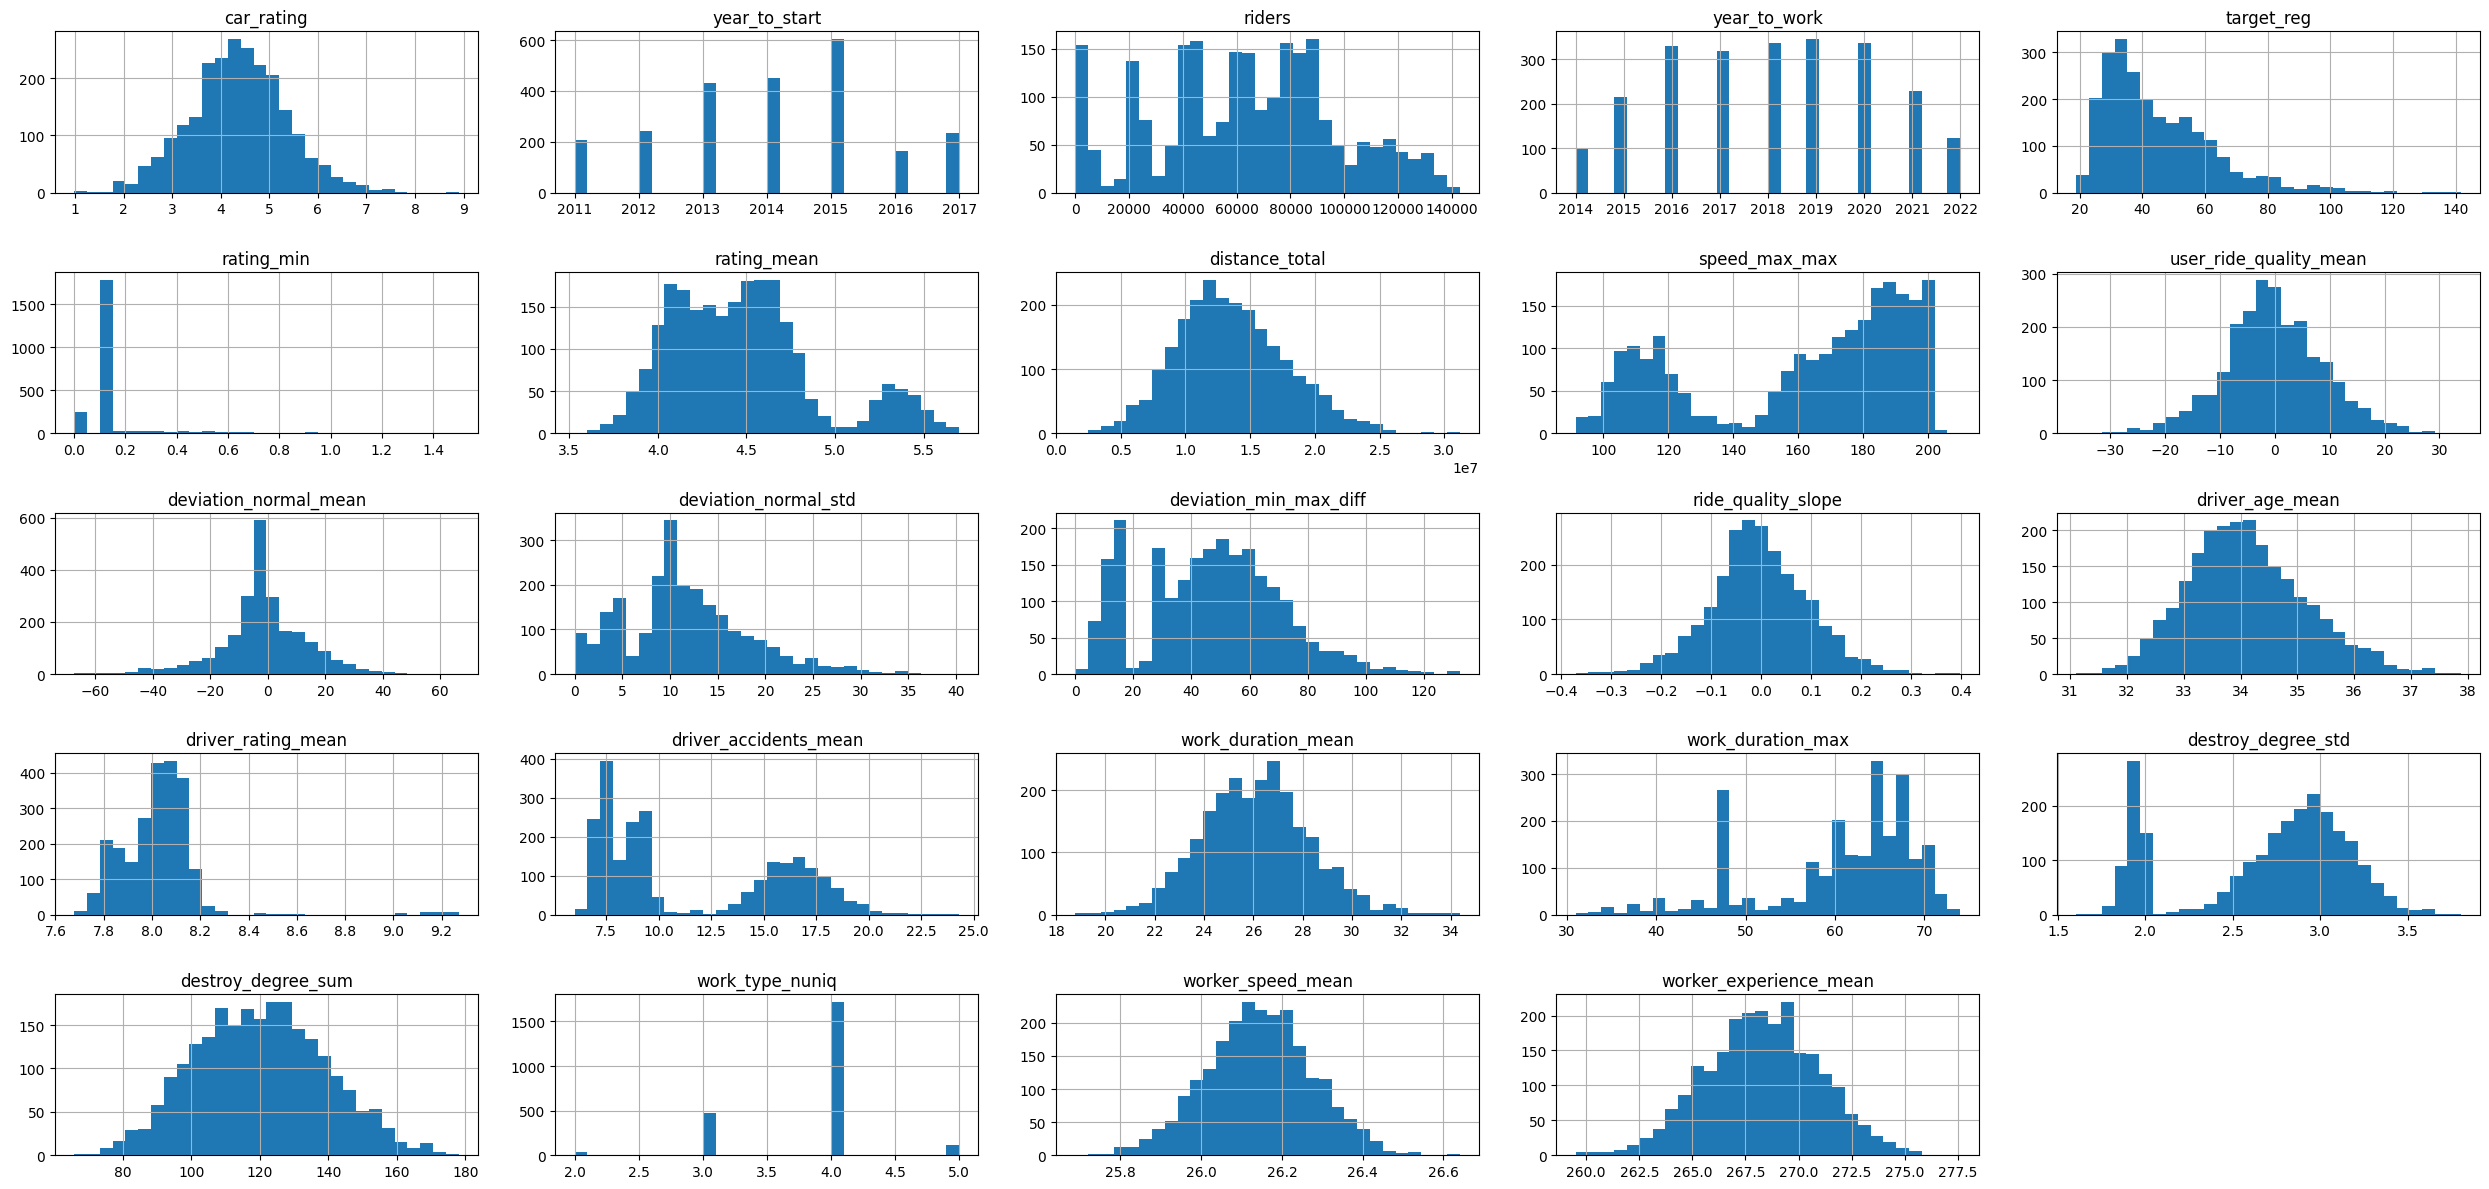


Итого признаков в df: 30
Строк: 2337
Столбцы: ['car_id', 'model', 'car_type', 'fuel_type', 'car_rating', 'year_to_start', 'riders', 'year_to_work', 'target_reg', 'target_class', 'rating_min', 'rating_mean', 'distance_total', 'speed_max_max', 'user_ride_quality_mean', 'deviation_normal_mean', 'deviation_normal_std', 'deviation_min_max_diff', 'ride_quality_slope', 'driver_age_mean', 'driver_rating_mean', 'driver_accidents_mean', 'work_duration_mean', 'work_duration_max', 'destroy_degree_std', 'destroy_degree_sum', 'work_type_nuniq', 'work_type_mode', 'worker_speed_mean', 'worker_experience_mean']


In [ ]:
num_cols = df.select_dtypes(include='number').columns.tolist()
df[num_cols].hist(figsize=(25, 12), layout=(-1, 5), bins=30)
plt.tight_layout()
plt.show()

print(f"\nИтого признаков в df: {df.shape[1]}")
print(f"Строк: {df.shape[0]}")
print(f"Столбцы: {df.columns.tolist()}")

In [ ]:
!pip install catboost shap phik boostaroota -q

import warnings
warnings.filterwarnings("ignore")

from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
import shap
import phik
from phik.report import plot_correlation_matrix

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 61.8 MB/s eta 0:00:00


### Метод 1: Линейная корреляция

In [ ]:
cols2drop = ['car_id', 'target_class', 'target_reg']
cat_cols = [c for c in ['model', 'car_type', 'fuel_type', 'work_type_mode'] if c in df.columns]

X = df.drop(cols2drop, axis=1, errors='ignore')
y = df['target_class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

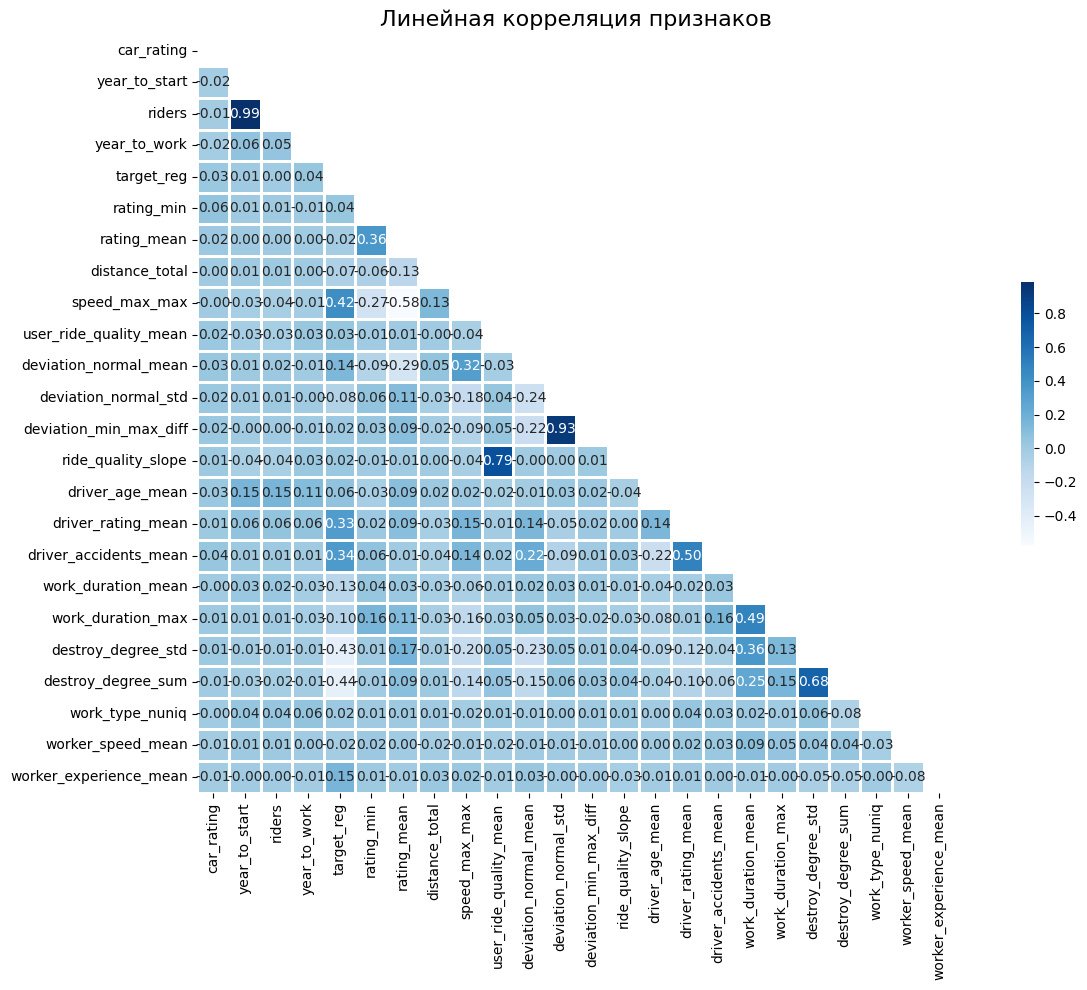

In [ ]:
corrs = df.select_dtypes(include='number').corr().round(3)
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corrs, dtype=bool))
sns.heatmap(
    corrs, annot=True, square=True, cmap="Blues",
    cbar_kws={"fraction": 0.01}, linewidth=1, fmt='.2f', mask=mask,
)
plt.title("Линейная корреляция признаков", fontsize=16)
plt.tight_layout()
plt.show()

### Метод 2: Phik корреляция

interval columns not set, guessing: ['car_rating', 'year_to_start', 'riders', 'year_to_work', 'target_reg', 'rating_min', 'rating_mean', 'distance_total', 'speed_max_max', 'user_ride_quality_mean', 'deviation_normal_mean', 'deviation_normal_std', 'deviation_min_max_diff', 'ride_quality_slope', 'driver_age_mean', 'driver_rating_mean', 'driver_accidents_mean', 'work_duration_mean', 'work_duration_max', 'destroy_degree_std', 'destroy_degree_sum', 'work_type_nuniq', 'worker_speed_mean', 'worker_experience_mean']


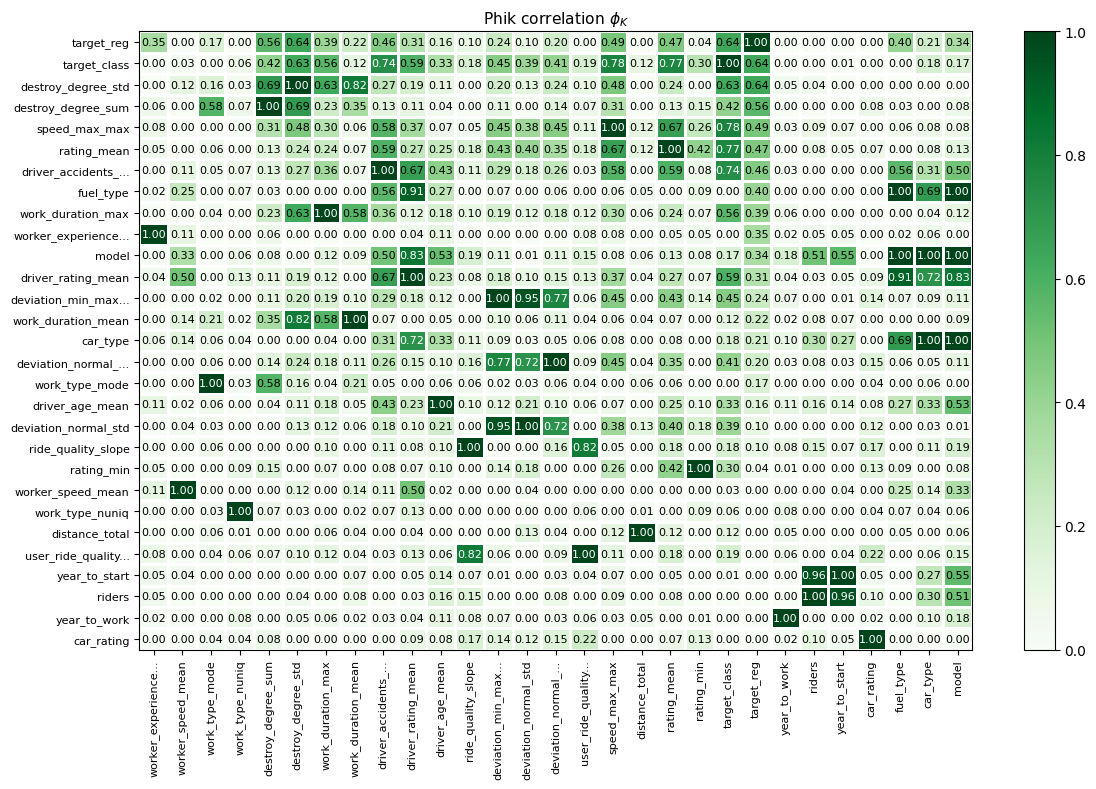

In [ ]:
phik_overview = df.drop(columns=['car_id'], errors='ignore').phik_matrix().round(2).sort_values('target_reg')
plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map="Greens",
    title=r"Phik correlation $\phi_K$",
    fontsize_factor=0.8, figsize=(12, 8)
)
plt.tight_layout()
plt.show()

### Метод 3: CatBoost Feature Importance

CatBoost Feature Importance:
                Feature Id  Importances
0    driver_accidents_mean    28.240477
1       destroy_degree_std    21.556297
2            speed_max_max    19.051037
3              rating_mean    15.104782
4       driver_rating_mean     5.482648
5               rating_min     2.822090
6                    model     0.951038
7          driver_age_mean     0.915378
8                 car_type     0.737703
9        work_duration_max     0.723927
10  deviation_min_max_diff     0.633693
11      destroy_degree_sum     0.598702
12   deviation_normal_mean     0.581695
13       worker_speed_mean     0.398302
14    deviation_normal_std     0.316279
15  worker_experience_mean     0.293805
16              car_rating     0.270942
17      work_duration_mean     0.236033
18          distance_total     0.222587
19  user_ride_quality_mean     0.208983
20      ride_quality_slope     0.200485
21                  riders     0.195947
22            year_to_work     0.117894
23         

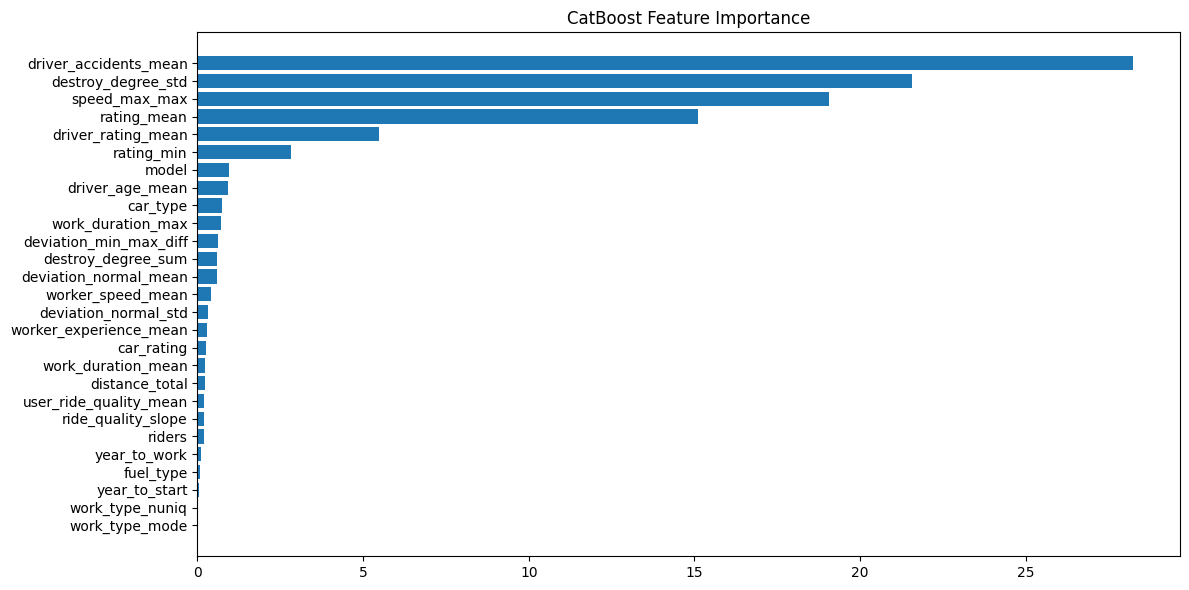

In [ ]:
model = CatBoostClassifier(
    random_state=42, cat_features=cat_cols, thread_count=-1, verbose=0,
)
model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=100)

fi = model.get_feature_importance(prettified=True)
print("CatBoost Feature Importance:")
print(fi.to_string())

feature_importance = model.feature_importances_
sorted_idx = np.argsort(feature_importance)
plt.figure(figsize=(12, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(X.columns)[sorted_idx])
plt.title('CatBoost Feature Importance')
plt.tight_layout()
plt.show()

### Метод 4: SHAP values

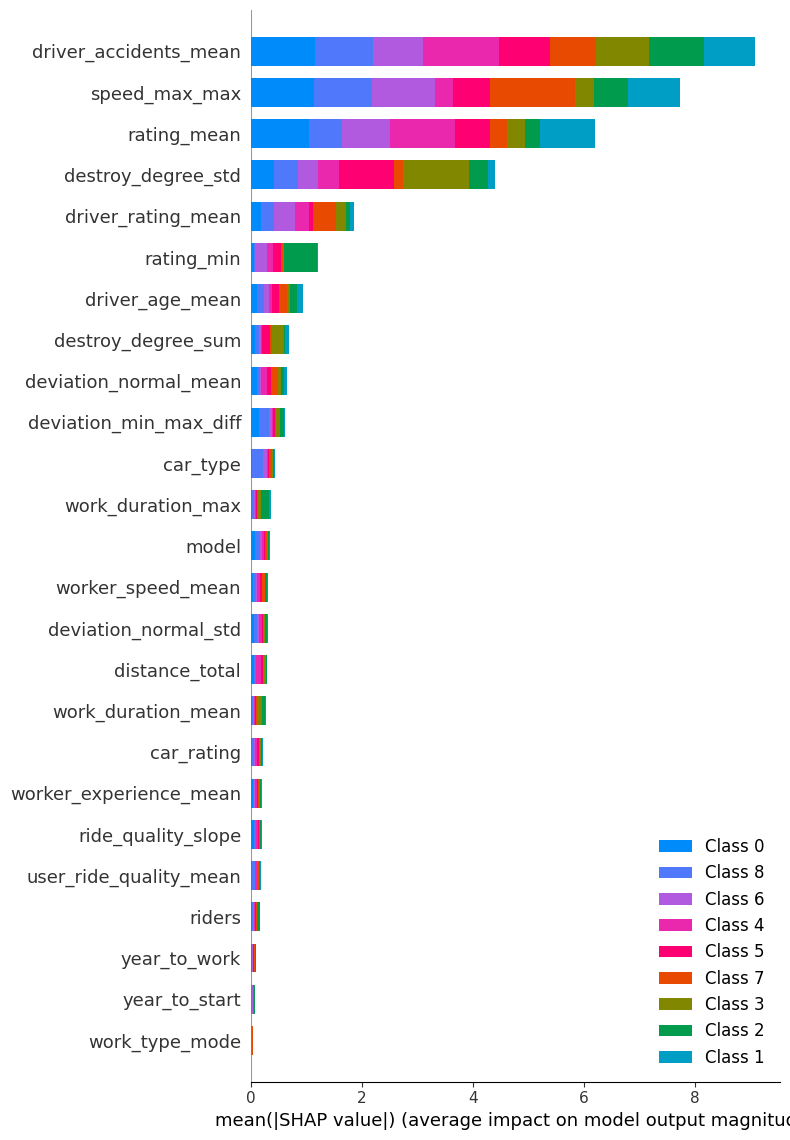

In [ ]:
explainer = shap.TreeExplainer(model)
val_dataset = Pool(data=X_test, label=y_test,
cat_features=cat_cols)
shap_values = explainer.shap_values(val_dataset)
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=25)

### Метод 5: CatBoost select_features (RecursiveByShapValues)

In [ ]:
summary = model.select_features(
    X_train, y_train,
    eval_set=(X_test, y_test),
    features_for_select=list(range(X_train.shape[1])),
    num_features_to_select=max(8, X_train.shape[1] // 2),
    steps=3,
    train_final_model=False,
    logging_level='Silent',
    algorithm='RecursiveByShapValues',
)
print("\nCatBoost select_features (RecursiveByShapValues):")
print(f"  Отобранные признаки: {summary['selected_features_names']}")
print(f"  Удалённые признаки: {summary['eliminated_features_names']}")
print(f"  Best loss: {summary['loss_graph']['loss_values'][-1]:.4f}")


CatBoost select_features (RecursiveByShapValues):
  Отобранные признаки: ['car_type', 'fuel_type', 'rating_min', 'rating_mean', 'speed_max_max', 'user_ride_quality_mean', 'deviation_normal_mean', 'deviation_normal_std', 'driver_rating_mean', 'driver_accidents_mean', 'destroy_degree_std', 'work_type_mode', 'worker_experience_mean']
  Удалённые признаки: ['model', 'distance_total', 'work_duration_mean', 'driver_age_mean', 'riders', 'worker_speed_mean', 'deviation_min_max_diff', 'work_duration_max', 'year_to_work', 'year_to_start', 'ride_quality_slope', 'work_type_nuniq', 'destroy_degree_sum', 'car_rating']
  Best loss: 0.0538


### Метод 6: Boruta

In [ ]:
!pip install boruta -q
from boruta import BorutaPy
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 5.2 MB/s eta 0:00:00


In [ ]:
from sklearn.preprocessing import LabelEncoder

cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

X_train_ohe = pd.get_dummies(X_train[cat_cols])
X_train_br = pd.concat((X_train.drop(columns=cat_cols), X_train_ohe), axis=1).fillna(0).astype(float)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)

In [ ]:
forest = RandomForestClassifier(
n_jobs = -1,
max_depth=None
)
boruta = BorutaPy(
estimator = forest,
n_estimators = 'auto',
max_iter = 30, # number of trials to perform
verbose=1
)

boruta.fit(np.array(X_train_br), y_train_enc)

green_area = X_train_br.columns[boruta.support_].to_list()
blue_area = X_train_br.columns[boruta.support_weak_].to_list()
red_area = X_train_br.columns[~(boruta.support_ | boruta.support_weak_)].to_list()

print('features in the green area:', green_area)
print('features in the blue area:', blue_area)
print('features in the red area:', red_area)

Iteration: 1 / 30
Iteration: 2 / 30
Iteration: 3 / 30
Iteration: 4 / 30
Iteration: 5 / 30
Iteration: 6 / 30
Iteration: 7 / 30
Iteration: 8 / 30
Iteration: 9 / 30
Iteration: 10 / 30
Iteration: 11 / 30
Iteration: 12 / 30
Iteration: 13 / 30
Iteration: 14 / 30
Iteration: 15 / 30
Iteration: 16 / 30
Iteration: 17 / 30
Iteration: 18 / 30
Iteration: 19 / 30
Iteration: 20 / 30
Iteration: 21 / 30
Iteration: 22 / 30
Iteration: 23 / 30
Iteration: 24 / 30
Iteration: 25 / 30
Iteration: 26 / 30
Iteration: 27 / 30
Iteration: 28 / 30
Iteration: 29 / 30


BorutaPy finished running.

Iteration: 	30 / 30
Confirmed: 	15
Tentative: 	1
Rejected: 	41
features in the green area: ['rating_min', 'rating_mean', 'distance_total', 'speed_max_max', 'user_ride_quality_mean', 'deviation_normal_mean', 'deviation_normal_std', 'deviation_min_max_diff', 'ride_quality_slope', 'driver_age_mean', 'driver_rating_mean', 'driver_accidents_mean', 'work_duration_max', 'destroy_degree_std', 'destroy_degree_sum']
features in the bl

### Выводы

1. **Константы и почти-константы** удалены сразу: `ride_count` (одно значение 174) и `worker_count` (только 34/35).

2. **Надёжные признаки** — стабильно в топе по CatBoost FI, SHAP, RecursiveByShapValues и Boruta:
   `driver_accidents_mean`, `destroy_degree_std`, `speed_max_max`, `rating_mean`, `driver_rating_mean`, `rating_min`, `deviation_normal_mean/std`.

3. **Слабые признаки** — отфильтрованы несколькими методами одновременно:
   `year_to_start`, `riders`, `year_to_work`, `car_rating`, `work_type_nuniq`, `worker_speed_mean`.

4. **Линейная корреляция**: `year_to_start` и `riders` сильно коррелируют (>0.98), можно удалить один.

5. **Phik** подтверждает значимость `speed_max_max`, `rating_mean`, `deviation_normal_mean` и ловит нелинейные связи с категориальными признаками.

6. **CatBoost RecursiveByShapValues** отобрал 13 из 27 признаков с лучшим loss = 0.054.

7. **Boruta** подтвердил 15 признаков.

# Домашнее задание 2. Прогноз времени и вида поломки машин. Настройка ML-модели

<div class="alert alert-info">

**Цель блока** — составить тренировочную и валидационную выборки, произвести обучение модели `CatBoostClassifier` на тренировочной части и оценить качество на валидационной.

## 1. Обучение первой модели (5 баллов)

1. Классифицируйте признаки на типы (категориальные, числовые, таргеты).

2. Выделите в `X` только признаки (убрать оба таргета), а в `Y` — таргет (для задачи классификации).

3. Сделайте разделение данных на *обучающую* и *валидационную* выборки (не забывайте про воспроизводимость результатов).

4. Создайте и обучите `CatBoostClassifier` модель (настраивать гиперпараметры сейчас не обязательно). Отключите или минимизируйте логирование при обучении.

5. Проведите оценку вашей модели, используя метрику `accuracy`.


<h4> Критерии оценивания </h4> По 1 баллу за каждый корректно выполненный пункт.

</div>

In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [92]:
features2drop = [
    'car_id',
    'year_to_start',
    'riders',
    'year_to_work',
    'car_rating',
    'work_type_nuniq',
    'worker_speed_mean',
]
targets = ['target_class', 'target_reg']
cat_features = ['model', 'car_type', 'fuel_type', 'work_type_mode']

num_features = [c for c in df.columns if c not in features2drop + targets + cat_features]

print('Категориальные признаки:', len(cat_features), cat_features)
print('Числовые признаки:', len(num_features), num_features)
print('Целевые переменные', targets)

Категориальные признаки: 4 ['model', 'car_type', 'fuel_type', 'work_type_mode']
Числовые признаки: 17 ['rating_min', 'rating_mean', 'distance_total', 'speed_max_max', 'user_ride_quality_mean', 'deviation_normal_mean', 'deviation_normal_std', 'deviation_min_max_diff', 'ride_quality_slope', 'driver_age_mean', 'driver_rating_mean', 'driver_accidents_mean', 'work_duration_mean', 'work_duration_max', 'destroy_degree_std', 'destroy_degree_sum', 'worker_experience_mean']
Целевые переменные ['target_class', 'target_reg']


## 2. Визуализация прогнозов, ошибок модели и важности признаков (5 баллов)

<div class="alert alert-info">

**Цель блока** — визуализировать результаты прогнозирования, ошибки модели и важность признаков для лучшего понимания и анализа модели.

   
1. Визуализируйте важность признаков встроенным методом в `CatBoost`  (помните, что не стоит сильно доверять этому рейтингу важности, т. к. для сильно скоррелированных признаков важность делится пополам — оба признака могут «улететь» вниз).

2. Постройте `waterfall_plot` из библиотеки `SHAP` (подробнее во втором ноутбуке из полезных ссылок ниже).
    
3. Постройте `classification_report` из библиотеки `scikit-learn`.

4. Постройте и визуализируйте матрицу смежности (`confusion_matrix`), посмотрите, в каких классах модель больше всего ошибается.
    
5. Для каждого графика/примененного метода проинтерпретируйте результаты и сделайте выводы.


<h4> Критерии оценивания </h4>
    
По 1 баллу за каждый корректно выполненный пункт.
    
</div>

<div class="alert alert-success">

Визуализация может помочь даже после того, как мы **уже обучили** какую-нибудь модель. Например:

- понять, что мешает модели или чего не хватает, чтобы не допускать ошибки;
- сделать выводы, как можно улучшить точность в последующих экспериментах;
- визуализировать ошибки модели;
- отсеять лишние признаки;
- найти идеи для новых признаков.

Все зависит от типа ваших данных.

<h3> Полезные источники </h3>
    
- Занятие про визуализацию и Seaborn.
- Занятие про продвинутую визуализацию и анализ ошибок модели.

</div>    

In [ ]:
# YOUR CODE HERE

# Домашнее задание 3. Оптимизация. Тюнинг гиперпараметров с помощью `Optuna` (10 баллов)

<div class="alert alert-info">

**Цель блока** — улучшить качество предсказания, произведя подбор гиперпараметров для модели с помощью `Optuna`.

1. Напишите `objective` функцию и запустите `Optuna` (минимум 50 итераций).
2. Подберите гиперпараметры для `CatBoostClassifier` (минимум 3).
3. Обучите модель с новыми гиперпараметрами, сравните качество и сделайте выводы.
4. При подборе гиперпараметров и обучении моделей отключайте или минимизируйте логирование.

<h4> Критерии оценивания </h4>
    
* За корректный `objective` и запуск подбора — 3 балла.
* За корректный выбор гиперпараметров для оптимизации — 3 балла.
* Обучение модели с подобранными гиперпараметрами — 3 балла.
* За корректную работу с логами — 1 балл.
    
</div>

In [ ]:
# YOUR CODE HERE

### Общая информация по `Optuna`

#### Ключевые особенности <code>Optuna</code>



- Легковесность и универсальность — можно подбирать оптимальные параметры под любые функции и метрики.
- SOTA-алгоритмы, адаптированные для поиска гиперпараметров.
- Параллелизация и различные методы прунинга.
- Встроенная визуализация.
- Интеграция со множеством популярных библиотек (бустинги, sklearn, PyTorch, W&B и другие).

Разберем Optuna по частям, чтобы понять, как ее использовать.

#### <code>Study</code>: оптимизация, базирующаяся на <code>Objective</code> функции



В `Objective`-функцию нужно написать код подсчета метрики, которую возвращаем. `Objective` вызывается Optuna много раз для подбора лучших параметров.
```python
def objective(trial, ...):
    # calculate score...
    return score
```

<h4> <code>Trial</code> — одно выполнение <code>Objective</code>-функции</h4>

В `trial`-объекте мы передаем параметры для перебора, используя для каждого типа свой метод. Например:

```python
# метод `suggest_float` показывает, что перебираем `float` значения, от 0 и до 1.5 границы
param = trial.suggest_float('param', 0, 1.5)

# Категориальное значение
loss_function = trial.suggest_categorical('loss', ['Logloss', 'CrossEntropy'])

# Целочисленное значение
depth = trial.suggest_int('depth', 5, 8)

# Равномерное распределение
learning_rate = trial.suggest_uniform('learning_rate', 0.0, 1.0)
```

#### `Study` parameters

Инициализируем объект `study`, который начнет перебор и сохранит в себе историю результатов.
Если мы стараемся увеличить метрику, а не уменьшить ошибку, то используем `create_study(direction='maximize')`.
```python
study = optuna.create_study()
study.optimize(objective, n_trials=10)
```

<div class="alert alert-info">
    
В [`Optuna`](https://optuna.readthedocs.io/en/stable/index.html) реализовано несколько методов (`sampler`) подбора параметров (в том числе классические):
* `GridSampler`;
* `RandomSampler`;
* `Tree-Structed Parzen Estimator` (`TPESampler` — самый популярный, дефолтный);
* `BruteForceSampler`;
* [другие 4 метода](https://optuna.readthedocs.io/en/stable/reference/samplers/index.html#module-optuna.samplers) (можно написать собственный сэмплер).

### Советы по перебору параметров

- Иметь понимание важности параметров.
- Число `iterations` лучше взять с запасом и зафиксировать, при этом ограничив через `early_stopping_rounds`.
- Подсмотреть или чувствовать диапазоны и шаг значений.
- Исключить то, что перебирать не нужно (`random_seed` , `eval_metric`, `thread_count` и прочее).
- Использовать информацию с прошлых попыток.

# Домашнее задание 4. Блендинг

<div class="alert alert-info">

**Цель блока** — улучшить качество предсказания, объединив несколько моделей вместе методом блендинга.

1. Построить и обучить модели:


    - `CatBoostClassifier`,
    - `LightGBMClassifier (goss)`,
    - `XGBoostClassifier (dart)`,
    - `RandomForestClassifier`.
2. Сделать предсказания каждой моделью, оценить качество.
3. Реализовать блендинг двумя способами, оценить качество и сравнить с предыдущим пунктом:
    - `Hard Voting` —  метод, при котором делаем голосование всех моделей и выбираем самый популярный класс.
    - `Soft Voting` —  метод, при котором мы складываем вероятности предсказания всех моделей по каждому классу и потом выбираем самый класс с максимальной суммой.

    Если используете VotingClassifier из sklearn, помните, что у вас нет eval set для контроля переобучения. Поэтому стоит предварительно провести подбор гиперпараметров.
4. Отключайте или минимизируйте логирование (иначе будут снижаться баллы).
    
<h4> Критерии оценивания </h4>
    
- Обучены 4 модели — 2 балла за каждую обученную модель, всего 8 баллов.
- Для модели проведен подбор гиперпараметров — 1 балл за каждый параметр, всего 4 балла.
- Сделаны предсказания каждой модели и оценено качество — 2 балла.
- Реализован `Hard Voting` — 2 балла.
- Реализован `Soft Voting` — 2 балла.
- Сделаны выводы — 2 балла.

Итоговая оценка = полученный балл / 2
</div>

### Общая информация о блендинге

**Основная идея** — взять от каждого алгоритма лучшее и совместить несколько разных ML-моделей в одну.

Что это дает:
- Увеличивается обобщающая способность финальной модели и качество улучшается.
- Модель становится более стабильной, что позволяет не слететь на приватном лидерборде.

Особенно хорошо накидывает блендинг, если смешиваемые модели имеют разную природу — например, нейронные сети, kNN и решающие деревья. Они выучивают разные зависимости и хорошо дополняют друг друга.

</div>

# <center id="part6"> Отправка финального решения на лидерборд на Kaggle

<div class="alert alert-info">

**Цель блока** — сделать предсказание с помощью блендинга для тестовой части датасета, отправить результат [в соревнование на Kaggle](https://www.kaggle.com/t/bab924c25da94dcdb161fd1cef92fd97).

1. Сделать предобработку для тестового датасета, присоединить к нему информацию из других датасетов и добавить признаки, которые генерировали для тренировочного датасета.
2. Сделать предсказания каждой моделью, которую хотите включить в ансамбль, но минимум их должно быть 3.
3. Сделать блендинг с помощью `Hard Voting` или `Soft Voting` на ваш выбор.
4. Сохранить результат предсказания в `csv` файл и отправить решение на Kaggle.

</div>

In [ ]:
car_test = pd.read_csv('https://raw.githubusercontent.com/a-milenkin/Competitive_Data_Science/main/data/car_test.csv')
car_test.head(3)

In [ ]:
# YOUR CODE HERE

### Советы по отправке кода на Kaggle



Если пишете код на `Kaggle`, то для отправки решения нужно:

1. Нажать Save Version.
2. Проверить, что в Advanced Settings выбрано «Всегда сохранять результаты ноутбука».
3. Выбрать тип сохранения Save & Run All (Commit).
4. Нажать кнопку Save.

# Домашнее задание 5. Парсинг данных

**Цель задания** — собрать новый датасет с помощью парсинга данных.

**Формат сдачи**

Пришлите ссылку на репозиторий, в котором находятся:
* Jupiter Notebook с кодом;
* итоговый датасет — файл в формате .csv.

**Критерии оценки**:

* Датасет содержит все необходимые поля; размер датасета соответствует эталонному на 90% и более, обучена модель, отправлен сабмишн и выводы — 10 баллов.
* Датасет содержит все необходимые поля; размер датасета соответствует эталонному менее чем на 90%, правильная логика на этапах матчинга, парсинга доп. характеристик авто и мерджа с исходным датасетом — 8 баллов.
* Датасет содержит все или почти все необходимые поля; размер датасета соответствует эталонному менее чем на 90%; допущена серьезная ошибка на одном из этапов: матчинг, парсинг доп. характеристик авто и мердж с исходным датасетом — 6 баллов.
* Получилось спарсить ссылки на модели автомобилей — 4 балла.
* Код не исполняется; нет датасета — 1 балл.

## <center> Разминаемся
В качестве первого задания вам предстоит достать значения средних зарплат по городам России. Сайт, на котором они хранятся: https://stepik.org/media/attachments/lesson/866758/mean_salary_by_city.html

Ответ — датафрейм, котором города идут в алфавитном порядке.

Пример ответа:

<left> <img src='https://github.com/PeMikj/images/blob/main/images/image1.png?raw=true' width="550" >

## <center> Парсим [automobili.ru](https://automobili.ru/cars/catalog/)

В этой задаче вам предстоит спарсить дополнительные данные по моделям машин с сайта: https://automobili.ru/cars/catalog/ и добавить их в существующий датасет. Чтобы было проще понимать, в каком месте вы ошибаетесь (если такое происходит), мы разбили эту задачу на несколько степов, где постепенно будем парсить данный сайт.

<left> <img src='https://github.com/PeMikj/images/blob/main/images/image2.png?raw=true' width="750" >

## <center> Собираем ссылки

Чтобы начать доставать информацию о моделях, нужно вначале получить ссылки на эти модели. На первой странице сайта находится список всех марок. Вам нужно:

1) Собрать все ссылки на автомобильные бренды (средствами автоматического парсинга).

2) Пройтись по каждой из полученных ссылок и спарсить названия конкретных моделей автомобилей.

<left> <img src='https://github.com/PeMikj/images/blob/main/images/image3.png?raw=true' width="750" >
<left> <img src='https://github.com/PeMikj/images/blob/main/images/image4.png?raw=true' width="750" >

В итоге у вас должно найтись 325 ссылок, которые выглядят примерно так:

<left> <img src='https://github.com/PeMikj/images/blob/main/images/image5.png?raw=true' width="750" >

Ответ — датафрейм с ссылками и названием модели. Датафрейм должен быть отсортирован по названию модели, а затем по ссылкам.
`df.sort_values(by=['model', 'link'])`

Пример:

<left> <img src='https://github.com/PeMikj/images/blob/main/images/image6.png?raw=true' width="750" >

## <center>  Матчим ссылки с датасетом
 Мы получили ссылки на все модели машин, которые есть на сайте, но нам понадобится только небольшая часть, так как многие модели отсутствуют в изначальном датасете. В этом задании вам предстоит сопоставить ссылки и машины из датасета `quickstart_train.csv`.

In [ ]:
import pandas as pd

path = 'https://stepik.org/media/attachments/lesson/866758/quickstart_train.csv'

df = pd.read_csv(path)
df.head(3)

<left> <img src='https://github.com/PeMikj/images/blob/main/images/image7.png?raw=true' width="750" >
<left> <img src='https://github.com/PeMikj/images/blob/main/images/image8.png?raw=true' width="300" >

Далее нам нужно сматчить названия моделей машин в исходном и спаршенном датафреймах.
Для решения задачи можно использовать разные способы измерения близости между двумя строками.

Мы будем использовать алгоритм  нахождения наибольшей общей подпоследовательности ([Википедия](https://ru.wikipedia.org/wiki/%D0%9D%D0%B0%D0%B8%D0%B1%D0%BE%D0%BB%D1%8C%D1%88%D0%B0%D1%8F_%D0%BE%D0%B1%D1%89%D0%B0%D1%8F_%D0%BF%D0%BE%D0%B4%D0%BF%D0%BE%D1%81%D0%BB%D0%B5%D0%B4%D0%BE%D0%B2%D0%B0%D1%82%D0%B5%D0%BB%D1%8C%D0%BD%D0%BE%D1%81%D1%82%D1%8C)).

Для каждой модели в нашем исходном датафрейме нужно:

1) Найти строку с названием модели в напаршенных данных с максимальным значением наибольшей общей подпоследовательности.

2) Нормализовать значение наибольшей общей подпоследовательности на длину строки в исходном датафрейме.

3) Отсечь те случаи, где нормализованное значение меньше 0.85.

4) Если не удалось найти матч — заполняем np.nan.


P.S. Также нужно заменить `vw` на `volkswagen` в изначальном датасете, чтобы было больше совпадений. Нужно понимать, что идеально сматчить не всегда получится, поэтому иногда приходится прибегать к эвристикам, но мы в данном задании этого делать не будем.

Пример матчинга между названиями машин в исходном датафрейме и напаршенном.
Для каждого названия авто из исходного датафрейма находится название из напаршенного с наибольшим значением наибольшей общей подпоследовательности.

<left> <img src='https://github.com/PeMikj/images/blob/main/images/image9.png?raw=true' width="550" >

## <center> Достаем технические характеристики

Ссылки мы достали, теперь пришло время получить необходимые данные из них. Это скриншот того, как выглядит страница сайта для конкретной модели (в нашем случае Renault Sandero):

<left> <img src='https://github.com/PeMikj/images/blob/main/images/image10.png?raw=true' width="750" >

Отсюда вам необходимо для каждой модели получить следующую информацию:



* `year` - год начала выпуска модели (целое число);
* `mod` - название модификации;
* `price` - рекомендованная цена (целое число);
* `engine` - тип двигателя;
* `power` - мощность в л.с.;
* `box` - тип коробки передач;
* `trans` - тип трансмиссии;
* `body` - тип кузова.

Это все можно сделать при помощи BeautifulSoap.

Мы берем значения только для самой первой модификации.

Далее соединяем с нашим исходным датасетом. `model` — столбец, по которому мы соединяем датасеты.

Получившийся датасет — решение задачи (не изменяйте порядок строк в изначальном датасете).

Пример результата (для удобства представления в исходном датасете сохранены только колонки `car_id` и `model`, но вам нужны все колонки из исходного датасета):

<left> <img src='https://github.com/PeMikj/images/blob/main/images/image11.png?raw=true' width="850" >

## <center> Тренировка с новыми данными

Обучите модель на обогащенном датасете и сравните результат с предыдущими.

Отправьте сабмишн на kaggle.

Сделайте выводы.